In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings

In [29]:
# Configuración visual
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

class RadialCutAnalyzer:
    def __init__(self, folder_path):
        """
        Herramienta para estudiar asimetría en cortes radiales específicos.
        Excluye automáticamente el Anillo Denso.
        """
        self.folder_path = folder_path
        self.df = pd.DataFrame()
        self.current_cut_data = None
        self.current_results = []
        
        # Definición de Bins de Theta (Estándar tesis)
        self.n_theta_bins = 6
        self.theta_labels = [] # Se llenan al cargar

    def load_data(self):
        """Carga parquets, limpia y calcula variables geométricas."""
        files = glob.glob(os.path.join(self.folder_path, "*.parquet"))
        if not files:
            print("❌ No se encontraron archivos .parquet")
            return

        print(f"📂 Cargando {len(files)} archivos...")
        df_list = [pd.read_parquet(f) for f in files]
        self.df = pd.concat(df_list, ignore_index=True)
        
        # 1. EXCLUIR ANILLO DENSO (90k)
        # Nos quedamos solo con Infill/Standard (IDs != 90xxx)
        self.df = self.df[~((self.df['counterId'] >= 90000) & (self.df['counterId'] < 100000))].copy()
        
        # 2. FILTROS BÁSICOS
        self.df = self.df[
            (self.df['nMuones_REC'].notna()) &
            (self.df['r_core'].notna())
        ].copy()

        # 3. GEOMETRÍA
        # Theta
        self.df['s2_theta'] = np.sin(np.deg2rad(self.df['theta_REC']))**2
        
        # Phi (Centrado en 0)
        phi_deg = np.rad2deg(self.df['phi_plane'])
        self.df['phi_deg'] = (phi_deg + 180) % 360 - 180
        
        # 4. BINNING EN THETA (Fijo para comparar)
        theta_max = min(65, self.df['theta_REC'].max())
        s2_bins = np.linspace(
            np.sin(np.deg2rad(self.df['theta_REC'].min()))**2,
            np.sin(np.deg2rad(theta_max))**2,
            self.n_theta_bins + 1
        )
        self.df['theta_bin'] = pd.cut(self.df['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)
        
        # Guardar etiquetas para plots
        edges = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))
        self.theta_labels = [f"{edges[i]:.1f}-{edges[i+1]:.1f}°" for i in range(len(edges)-1)]
        
        print(f"✅ Datos listos: {len(self.df)} módulos (Sin Anillo Denso).")

    def _fit_func(self, phi, A1):
        # Fase fija en 0, Offset fijo en 1
        return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi)))

    def analizar_corte(self, r_min, r_max):
        """
        Analiza un anillo específico entre r_min y r_max.
        """
        print(f"\n🔍 Analizando Corte Radial: {r_min} m < r < {r_max} m")
        
        # 1. Filtrar por Radio
        self.current_cut_data = self.df[
            (self.df['r_core'] >= r_min) & 
            (self.df['r_core'] < r_max)
        ].copy()
        
        if self.current_cut_data.empty:
            print("⚠️ No hay datos en este rango radial.")
            return

        print(f"   -> Módulos encontrados: {len(self.current_cut_data)}")
        
        # 2. Ajuste por Bin de Theta
        phi_bins = np.linspace(-180, 180, 13)
        phi_centers = (phi_bins[:-1] + phi_bins[1:]) / 2
        
        results = []
        
        # Preparamos plot de validación (6 subplots)
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
        fig.suptitle(f"Ajustes de Modulación Azimutal (Radio {r_min}-{r_max} m)", fontsize=16)
        axes = axes.flatten()

        for i in range(self.n_theta_bins):
            ax = axes[i]
            subset = self.current_cut_data[self.current_cut_data['theta_bin'] == i]
            
            if len(subset) < 50:
                ax.text(0.5, 0.5, "Poca Estadística", ha='center')
                continue
                
            # Perfil
            subset['phi_hist'] = pd.cut(subset['phi_deg'], bins=phi_bins)
            stats = subset.groupby('phi_hist', observed=True)['nMuones_REC'].agg(['mean', 'std', 'count'])
            
            norm = stats['mean'].mean()
            y = stats['mean'] / norm
            yerr = (stats['std'] / np.sqrt(stats['count'])) / norm
            
            # Plot Datos
            ax.errorbar(phi_centers, y, yerr=yerr, fmt='o', color='navy', label='Datos')
            
            # Fit
            try:
                popt, pcov = curve_fit(self._fit_func, phi_centers, y, p0=[0.05], sigma=yerr)
                A1 = popt[0]
                A1_err = np.sqrt(pcov[0,0])
                
                # Plot Fit
                x_fit = np.linspace(-180, 180, 100)
                ax.plot(x_fit, self._fit_func(x_fit, *popt), 'r--', label=f'A1={A1:.3f}')
                
                results.append({'theta_bin': i, 'A1': A1, 'A1_err': A1_err})
            except:
                ax.text(0, 1.05, "Fit Falló")
            
            ax.set_title(self.theta_labels[i])
            ax.grid(True, alpha=0.3)
            if i == 0: ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()
        
        self.current_results = pd.DataFrame(results)
        
        # 3. Plot Resumen A1 vs Theta para este radio
        if not self.current_results.empty:
            self.plot_summary(r_min, r_max)

    def plot_summary(self, r_min, r_max):
        """Muestra A1 vs Theta para el corte actual."""
        fig, ax = plt.subplots(figsize=(8, 5))
        
        res = self.current_results
        ax.errorbar(res['theta_bin'], res['A1'], yerr=res['A1_err'], 
                    fmt='o-', color='darkgreen', capsize=4, label='UMD REC')
        
        ax.set_title(f"Amplitud de Asimetría vs Theta\nCorte Radial: {r_min} - {r_max} m")
        ax.set_xlabel("Bin de Theta")
        ax.set_ylabel(r"$A_1$")
        ax.set_xticks(range(self.n_theta_bins))
        ax.set_xticklabels(self.theta_labels)
        ax.axhline(0, color='gray', linestyle='--')
        ax.grid(True, alpha=0.5)
        
        plt.show()

📂 Cargando 20 archivos...
✅ Datos listos: 733080 módulos (Sin Anillo Denso).

🔍 Analizando Corte Radial: 400 m < r < 800 m
   -> Módulos encontrados: 275439


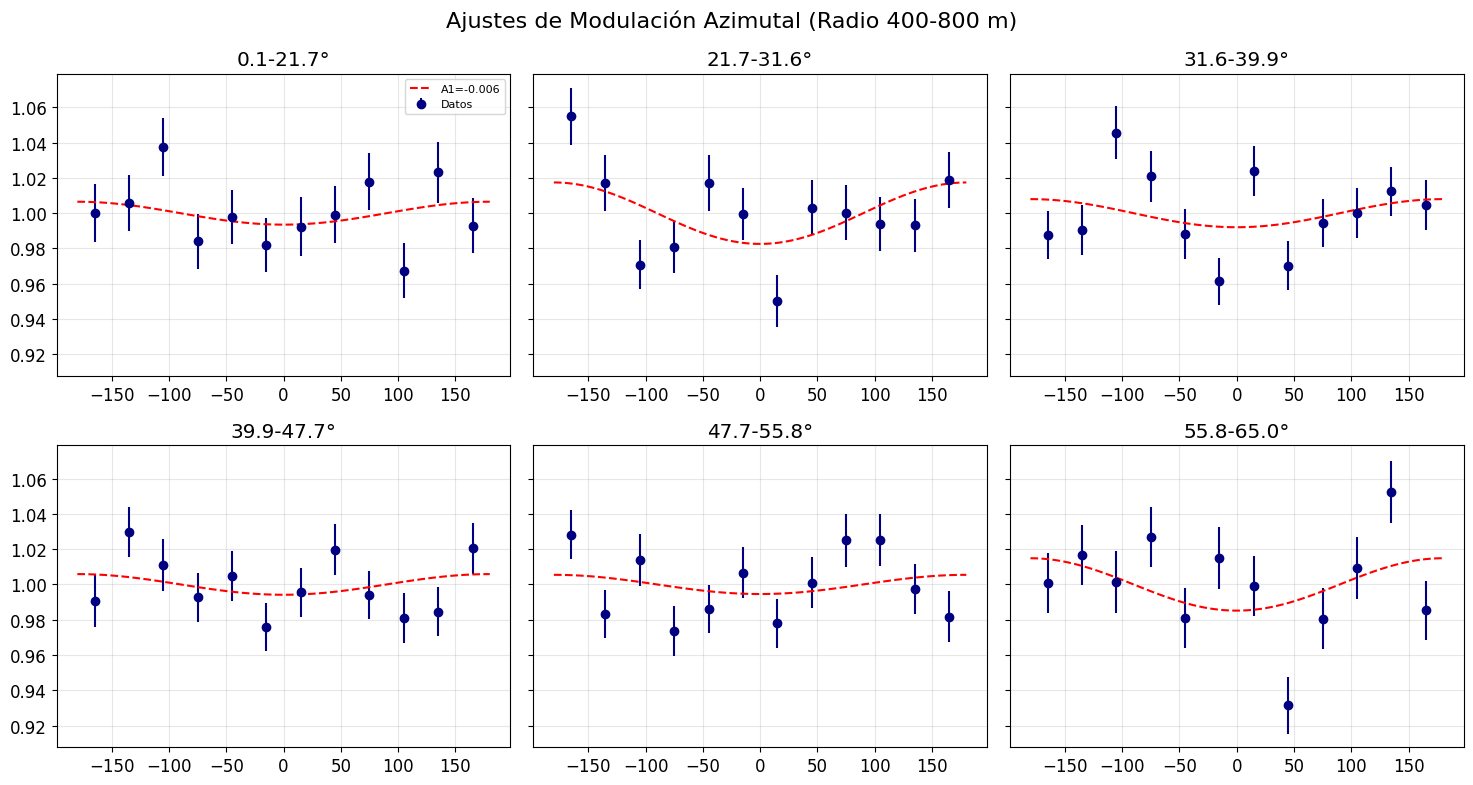

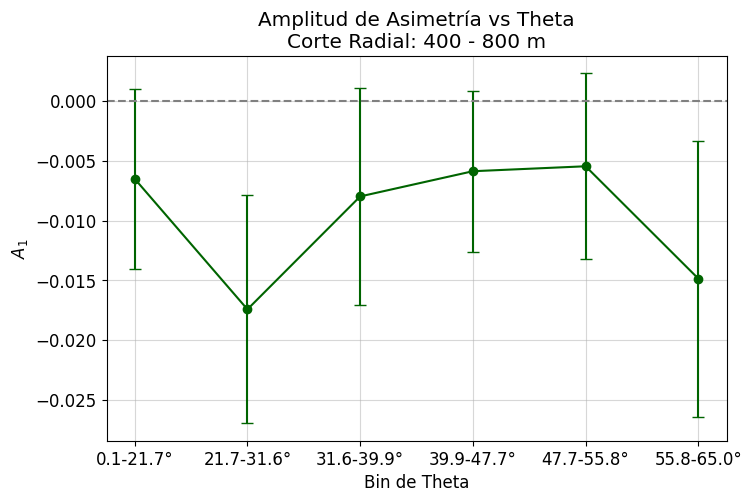

In [32]:
# --- EJEMPLO DE USO ---
# 1. Definí tu carpeta
folder = "/home/lsilva/Github/ADST_Alexey_module_v4/parquet_qgs_helio_17/" # Poné la ruta real acá

# 2. Instanciá y cargá
analyzer = RadialCutAnalyzer(folder)
analyzer.load_data()

# 3. ¡Jugá con los cortes! 
analyzer.analizar_corte(r_min=400, r_max=800)   # Cerca
# analyzer.analizar_corte(r_min=600, r_max=1000)  # Medio
# analyzer.analizar_corte(r_min=1000, r_max=2000) # Lejos

In [33]:
class RadialCutAnalyzer:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df = pd.DataFrame()
        self.current_cut_data = None
        
        # Usamos 6 bins de Theta estándar
        self.n_theta_bins = 6
        self.theta_labels = [] 

    def load_data(self):
        """Carga y Pre-procesa."""
        files = glob.glob(os.path.join(self.folder_path, "*.parquet"))
        if not files:
            print("❌ No hay parquets.")
            return

        print(f"📂 Cargando {len(files)} archivos...")
        df_list = [pd.read_parquet(f) for f in files]
        self.df = pd.concat(df_list, ignore_index=True)
        
        # 1. EXCLUIR ANILLO DENSO (Nos quedamos con el Infill)
        self.df = self.df[~((self.df['counterId'] >= 90000) & (self.df['counterId'] < 100000))].copy()
        
        # 2. FILTROS
        self.df = self.df[
            (self.df['nMuones_REC'].notna()) & (self.df['nMuones_REC'] > 0) & # Solo módulos con señal
            (self.df['r_core'].notna())
        ].copy()

        # 3. GEOMETRÍA
        self.df['s2_theta'] = np.sin(np.deg2rad(self.df['theta_REC']))**2
        phi_deg = np.rad2deg(self.df['phi_plane'])
        self.df['phi_deg'] = (phi_deg + 180) % 360 - 180
        
        # 4. BINNING THETA
        theta_max = min(65, self.df['theta_REC'].max())
        s2_bins = np.linspace(np.sin(np.deg2rad(0)), np.sin(np.deg2rad(theta_max)), self.n_theta_bins + 1)
        self.df['theta_bin'] = pd.cut(self.df['s2_theta'], bins=s2_bins, labels=False)
        
        edges = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))
        self.theta_labels = [f"{edges[i]:.0f}-{edges[i+1]:.0f}°" for i in range(len(edges)-1)]
        
        print(f"✅ Datos Infill cargados: {len(self.df)} módulos activos.")

    def _fit_func(self, phi, A1):
        return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi)))

    def analizar_corte(self, r_min, r_max):
        print(f"\n🔍 ANÁLISIS RADIO: {r_min} - {r_max} m")
        
        # Filtrar por radio
        subset = self.df[(self.df['r_core'] >= r_min) & (self.df['r_core'] < r_max)].copy()
        
        if subset.empty:
            print("⚠️ Sin datos en este rango.")
            return

        # --- DIAGNÓSTICO 1: ESTADÍSTICA ---
        mean_mu = subset['nMuones_REC'].mean()
        print(f"   -> Módulos: {len(subset)}")
        print(f"   -> Promedio de Muones por módulo: {mean_mu:.2f}")
        
        if mean_mu < 1.0:
            print("⚠️ ALERTA: Señal muy baja (<1 muón/módulo). Poisson domina todo.")

        # --- DIAGNÓSTICO 2: COBERTURA PHI (Aceptación) ---
        # Verificamos si la grilla del Infill nos da cobertura uniforme
        plt.figure(figsize=(6, 3))
        plt.hist(subset['phi_deg'], bins=24, color='gray', alpha=0.5, edgecolor='k')
        plt.title(f"Cobertura Azimutal en r={r_min}-{r_max}m")
        plt.xlabel("Phi (deg)")
        plt.ylabel("Cuentas (N Módulos)")
        plt.show()
        # Si este histograma tiene "huecos" o picos feos, ahí está tu problema.

        # --- ANÁLISIS DE ASIMETRÍA ---
        # Bins de Phi
        phi_bins = np.linspace(-180, 180, 13)
        phi_centers = (phi_bins[:-1] + phi_bins[1:]) / 2
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
        fig.suptitle(f"Modulación Normalizada (Radio {r_min}-{r_max} m)", fontsize=16)
        axes = axes.flatten()
        
        results_list = []

        for i in range(self.n_theta_bins):
            ax = axes[i]
            # Datos del bin angular
            df_bin = subset[subset['theta_bin'] == i].copy()
            
            if len(df_bin) < 100: continue

            # --- NORMALIZACIÓN CRÍTICA ---
            # Para evitar que una lluvia gigante domine el promedio, 
            # dividimos cada nMuon por el promedio global de este rango radial
            # (Una normalización mejor sería event-by-event, pero esto ayuda)
            global_avg = df_bin['nMuones_REC'].mean()
            df_bin['norm_signal'] = df_bin['nMuones_REC'] / global_avg

            # Agrupar por Phi
            df_bin['phi_bin_idx'] = pd.cut(df_bin['phi_deg'], bins=phi_bins)
            stats = df_bin.groupby('phi_bin_idx', observed=True)['norm_signal'].agg(['mean', 'std', 'count'])
            
            # Datos para plotear
            # Ya normalizamos antes, así que 'mean' debería estar cerca de 1.0
            y = stats['mean']
            # Error del promedio (SEM)
            yerr = stats['std'] / np.sqrt(stats['count'])
            
            # Plot
            ax.errorbar(phi_centers, y, yerr=yerr, fmt='o', color='navy', label='Data Norm')
            
            # Fit
            try:
                # p0=[0.05] -> semilla inicial 5% de asimetría
                popt, pcov = curve_fit(self._fit_func, phi_centers, y, p0=[0.05], sigma=yerr)
                A1 = popt[0]
                A1_err = np.sqrt(pcov[0,0])
                
                x_fit = np.linspace(-180, 180, 100)
                ax.plot(x_fit, self._fit_func(x_fit, *popt), 'r--', label=f'A1={A1:.3f}')
                
                results_list.append({'theta': i, 'val': A1, 'err': A1_err})
            except:
                ax.text(0, 1, "Fit Fail")

            ax.set_title(self.theta_labels[i])
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.85, 1.15) # Zoom en el 1.0
            if i==0: ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()
        
        # Resumen
        if results_list:
            res_df = pd.DataFrame(results_list)
            plt.figure(figsize=(6, 4))
            plt.errorbar(res_df['theta'], res_df['val'], yerr=res_df['err'], fmt='o-')
            plt.title(f"Resumen A1 vs Theta (r={r_min}-{r_max})")
            plt.ylabel("A1")
            plt.grid(True)
            plt.axhline(0, color='k', ls='--')
            plt.show()-

📂 Cargando 20 archivos...
✅ Datos Infill cargados: 461292 módulos activos.

🔍 ANÁLISIS RADIO: 400 - 800 m
   -> Módulos: 231033
   -> Promedio de Muones por módulo: 3.22


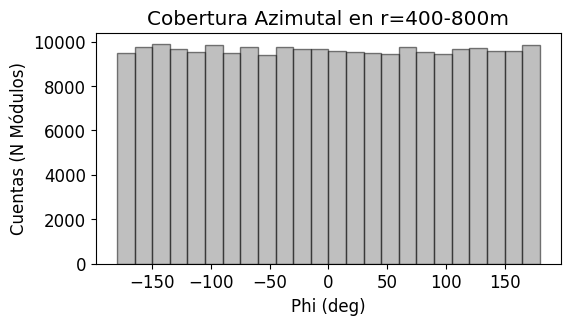

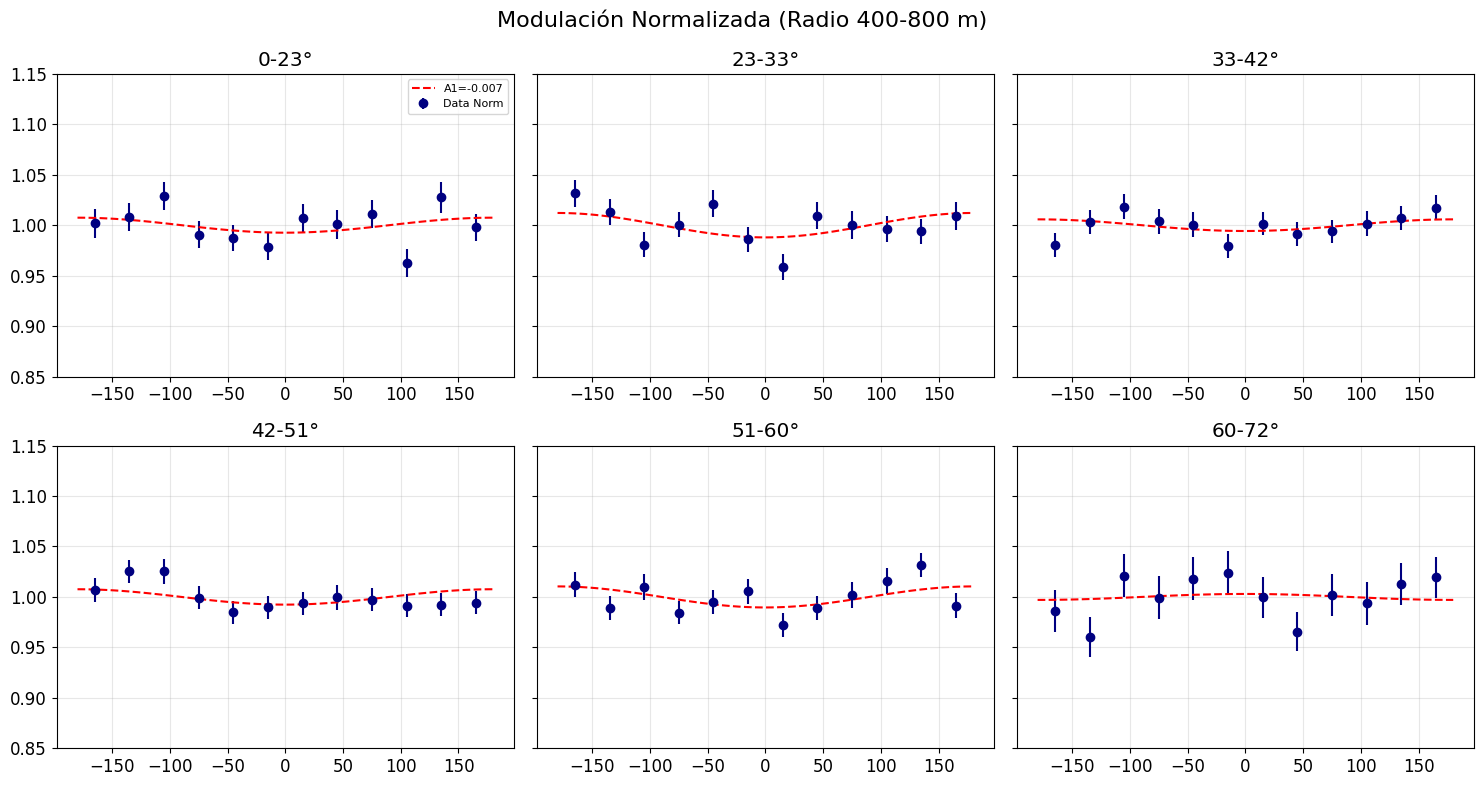

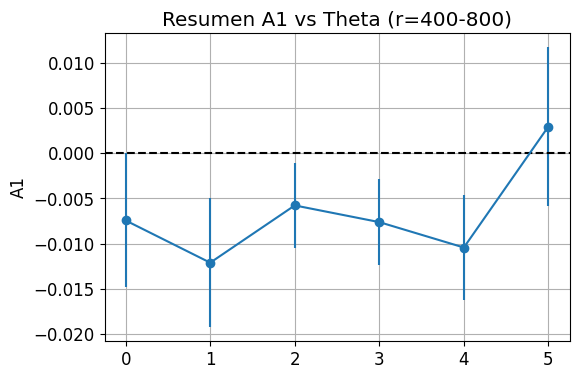

In [34]:
# --- EJEMPLO DE USO ---
# 1. Definí tu carpeta
folder = "/home/lsilva/Github/ADST_Alexey_module_v4/parquet_qgs_helio_17/" # Poné la ruta real acá

# 2. Instanciá y cargá
analyzer = RadialCutAnalyzer(folder)
analyzer.load_data()

# 3. ¡Jugá con los cortes! 
analyzer.analizar_corte(r_min=400, r_max=800)   # Cerca
# analyzer.analizar_corte(r_min=600, r_max=1000)  # Medio
# analyzer.analizar_corte(r_min=1000, r_max=2000) # Lejos